In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

In [4]:
# Load the data
ds = xr.open_dataset(
    data / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["wvpa"]

In [5]:
eb_abs = 1  # kg m-2

In [6]:
from numcodecs_wasm_zfp import Zfp

codec = Zfp(mode="fixed-accuracy", tolerance=eb_abs, non_finite="allow-unsafe")

In [7]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

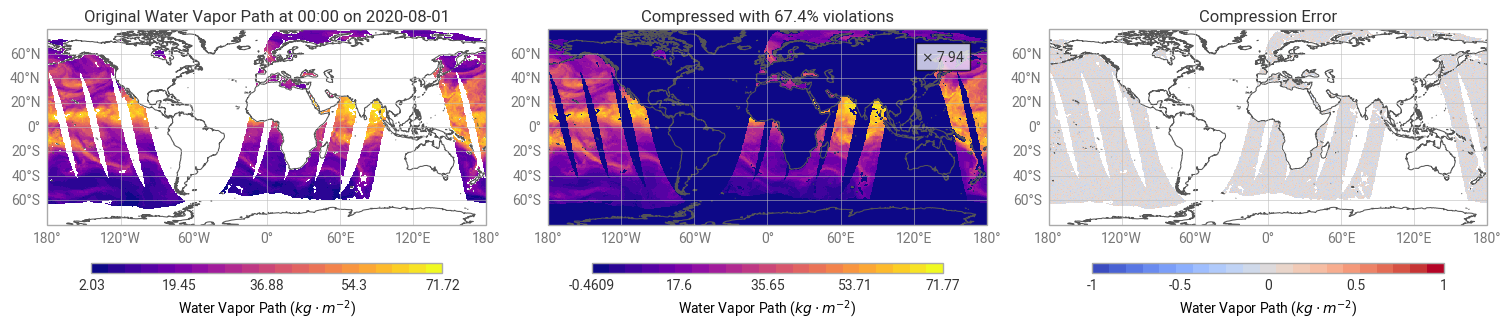

In [8]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

# violation if
# (a) the absolute error bound is exceeded
# (b) missing NaN values are not preserved
violations = np.mean(~((da_dec - da) <= eb_abs) | (np.isnan(da_dec) != np.isnan(da)))
violations = (
    0
    if violations == 0
    else np.format_float_positional(100 * violations, precision=1, min_digits=1) + "%"
)
if violations == "0.0%":
    violations = "<0.05%"

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title=f"Compressed with {violations} violations",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    da_dec - da,
    fig.add_map(0, 2),
    error=True,
    vrange=(-eb_abs, eb_abs),
    title="Compression Error",
)

fig.show()